<font color="#CA0032"><h1>Práctica B3-T5</h1></font>

# Construccion de redes neuronales con entradas heterogeneas

**Grupo:** Alonso Diaz &nbsp;&middot;&nbsp; Raul Rodriguez &nbsp;&middot;&nbsp; Piettro Enrico

---

## Planteamiento

La Práctica se basa en la competicion de Kaggle *Rossmann Store Sales*: predecir las **ventas diarias**
de una cadena de droguerias a partir de su histórico (2013 a julio de 2015), de las promociones, los
festivos y los Metadatos de cada tienda. El objetivo concreto es predecir las ventas de las **9 tiendas**
`[1, 2, 3, 4, 5, 562, 682, 733, 769]` maximizando el **R² en test**, donde el test son los datos desde el
**2015-01-01** (incluido). No se usa la variable `Customers` (esta trivialmente correlacionada con las
ventas y no se conoceria de antemano en un escenario real). El esquema es *many-to-one*: para predecir el
día `t` la red mira los `W` días anteriores.

En lugar de una única arquitectura, se comparan **estrategias de modelado** distintas sobre una base
común de datos, ventanas y partición temporal, de forma que la comparativa final sea justa:

| Estrategia | Idea | Nº de modelos |
|---|---|---|
| **A — Un modelo por tienda** | Una LSTM pequeña especializada en cada serie | 9 |
| **B — Un modelo por grupo** | Un modelo para las tiendas que cierran en domingo y otro para las que abren a diario | 2 |

El documento sigue este orden: carga y preprocesado, análisis exploratorio, preparacion común
(enventanado, objetivo y partición), cada estrategia con sus resultados, comparativa final y reflexión.

## 1. Configuracion

In [77]:
COLAB = False
RUTA_DATA = 'data'

# Tiendas objetivo del enunciado
TIENDAS = [1, 2, 3, 4, 5, 562, 682, 733, 769]
GRUPO_D = [1, 2, 3, 4, 5]
GRUPO_N = [562, 682, 733, 769]
GRUPOS = {'D (cierran domingos)': GRUPO_D, 'N (abre siempre)': GRUPO_N}

# Split temporal (enunciado)
F_TEST = np.datetime64('2015-01-01')
F_VAL  = np.datetime64('2014-11-15')

W = 28
SEED = 7

Se definen en una única celda las tiendas objetivo y su division en dos familias según el regimen de
apertura dominical (la division se justifica con datos en la sección 3). Centralizar la configuración
facilita repetir los experimentos con otra partición si hiciera falta.

In [78]:
import numpy as np, pandas as pd, zipfile, os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Flatten, concatenate, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

SEED = 7
np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


Se cargan las librerias y se fija la semilla de NumPy y TensorFlow para que los resultados sean
reproducibles (dentro de lo que permite el entrenamiento en paralelo de Keras).

## 2. Carga y union de datos

In [79]:
with zipfile.ZipFile(os.path.join(RUTA_DATA, 'train.zip')) as z:
    train = pd.read_csv(z.open('train.csv'), parse_dates=['Date'], low_memory=False)
store = pd.read_csv(os.path.join(RUTA_DATA, 'store.csv'))

df = train.merge(store, on='Store', how='left').sort_values(['Store', 'Date']).reset_index(drop=True)
df['StateHoliday'] = df['StateHoliday'].astype(str).replace('0', 'n')
df['Month'] = df.Date.dt.month
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompDistLog'] = np.log1p(df['CompetitionDistance'])
df['Promo2'] = df['Promo2'].fillna(0).astype(int)
df['y'] = np.log1p(df['Sales'])

# Filtramos
df9 = df[df.Store.isin(TIENDAS)].reset_index(drop=True)
print('df completo:', df.shape, '| df 9 tiendas:', df9.shape)
print('Grupos:', GRUPOS)

df completo: (1001599, 22) | df 9 tiendas: (8352, 22)
Grupos: {'D (cierran domingos)': [1, 2, 3, 4, 5], 'N (abre siempre)': [562, 682, 733, 769]}


Se une el histórico de ventas (`train.csv`) con los metadatos estáticos de cada tienda (`store.csv`) y se aplican los preprocesados básicos: los nulos de `CompetitionDistance` se imputan con la mediana y se pasa a escala logarítmica (su distribución es muy asimétrica), `StateHoliday` se normaliza como categórica y el objetivo se transforma a `log(1+Sales)`, que estabiliza la varianza y evita que las tiendas con más volumen dominen la función de pérdida. El dataset restringido a las 9 tiendas objetivo queda con unas 8.352 filas (9 tiendas x ~930 días).

## 3. Análisis exploratorio

Se examinan las 9 tiendas con dos preguntas en mente: como se comporta cada serie y si existe una
estructura natural de grupos que pueda explotarse en el modelado.

In [80]:
apertura = (df9.pivot_table(index='Store', columns='DayOfWeek', values='Open', aggfunc='mean') * 100).round(1)
apertura.columns = ['lun', 'mar', 'mie', 'jue', 'vie', 'sab', 'dom']
apertura['Grupo'] = ['D' if s in GRUPO_D else 'N' for s in apertura.index]
apertura

,lun,mar,mie,jue,vie,sab,dom,Grupo
Store,,,,,,,,
1,95.5,99.2,97.7,91.7,95.5,100.0,0.0,D
2,95.5,99.2,97.7,94.0,95.5,100.0,0.0,D
3,95.5,99.2,97.7,91.7,94.7,99.2,0.0,D
4,95.5,99.2,97.7,94.0,95.5,100.0,0.0,D
5,94.7,99.2,96.2,93.2,94.7,100.0,0.0,D
562,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N
682,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N
733,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N
769,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N


Se calcula el porcentaje de días abiertos por tienda y día de la semana. La columna `dom` separa perfectamente dos familias: las tiendas 1-5 abren un 0 % de los domingos y las 562/682/733/769 el 100 % de todos los días. No hay casos intermedios: la agrupación D/N que usa la estrategia B no es una elección arbitraria sino una dicotomía estructural del régimen de apertura. Se observa además que el grupo D tampoco abre todos los laborables (94-99 %, por festivos), mientras que el grupo N no cierra ni en festivo.

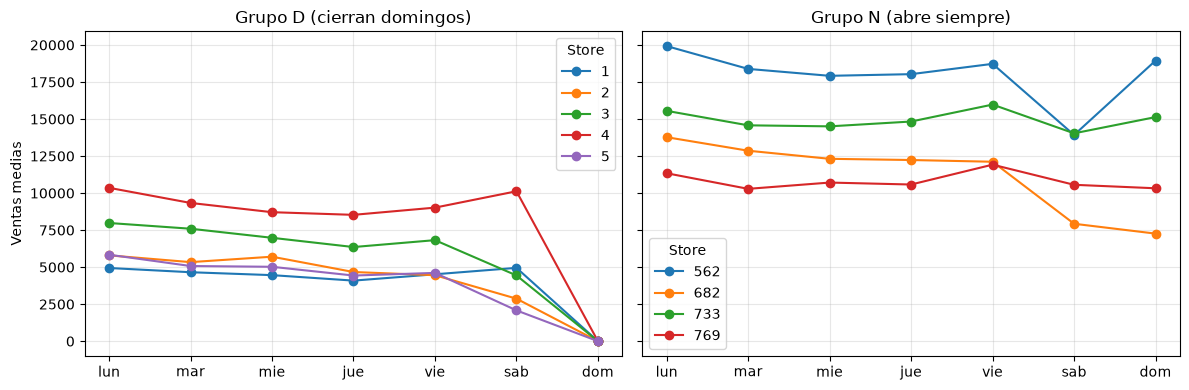

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
dias = ['lun', 'mar', 'mie', 'jue', 'vie', 'sab', 'dom']
for ax, (nombre, tiendas) in zip(axes, GRUPOS.items()):
    sub = df9[df9.Store.isin(tiendas)]
    perfil = sub.groupby(['Store', 'DayOfWeek'])['Sales'].mean().unstack(0)
    perfil.index = dias
    perfil.plot(ax=ax, marker='o')
    ax.set_title(f'Grupo {nombre}'); ax.set_ylabel('Ventas medias'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Se compara el perfil semanal medio de ventas de cada familia. El grupo D muestra la semana tipica de
tienda de barrio: pico el lunes, valle a mitad de semana y cero el domingo. En el grupo N el domingo no
solo existe: para varias tiendas es el día mas fuerte de la semana, ademas de moverse en niveles de venta
claramente superiores. Son dos procesos generadores distintos, y a la vez cada tienda tiene su propio
nivel y su propia sensibilidad a las promociones: esta tension entre lo común y lo particular es
exactamente lo que las estrategias A y B resuelven de maneras opuestas.

In [82]:
filas = []
for nombre, tiendas in GRUPOS.items():
    sub = df9[(df9.Store.isin(tiendas)) & (df9.Open == 1)]
    dom = sub[sub.DayOfWeek == 7]['Sales']
    filas.append({
        'Grupo': nombre,
        'Ventas medias (abierto)': round(sub.Sales.mean()),
        'CV ventas': round(sub.Sales.std() / sub.Sales.mean(), 3),
        'Ventas medias domingo': round(dom.mean()) if len(dom) else 0,
        '% dias festivo abierta': round((sub.StateHoliday != 'n').mean() * 100, 2),
    })
pd.DataFrame(filas)

,Grupo,Ventas medias (abierto),CV ventas,Ventas medias domingo,% dias festivo abierta
0,D (cierran domingos),6199,0.418,0,0.13
1,N (abre siempre),13740,0.283,12916,2.86


Los estadísticos resumen la diferencia de regimen: el grupo N vende mas del doble de media que el D
(~13.700 frente a ~6.200), con menor dispersion relativa (CV 0,28 frente a 0,42), y es el único que
registra ventas en domingo y festivo.

## 4. Preparacion común: ventanas, objetivo y partición

Todas las estrategias comparten estas Decisiones, de modo que las diferencias de resultados se deban solo
a la estrategia de modelado:

- **Ventanas**: para cada día objetivo `t`, la red recurrente ve una ventana de `W = 28` días con cuatro
  canales (`log_sales`, `Promo`, `SchoolHoliday`, `Open`), mas las exogenas del día `t`, lags semanales
  (`t-7`, `t-14`), estadísticos de la ventana y las categoricas via embeddings. Las ventanas nunca cruzan
  la frontera entre tiendas.
- **Objetivo residual**: en lugar de predecir `log(1+Sales)` directamente, las redes predicen el residuo
  `log(1+Sales) - media_td`, donde `media_td` es la media historica (calculada solo con datos de
  entrenamiento) de esa tienda para ese día de la semana, en escala log. En pruebas preliminares,
  prediciendo el objetivo en bruto los modelos no fijaban bien el nivel medio de cada tienda y quedaban
  por debajo del baseline de medias; con el residuo, el nivel y la estacionalidad semanal base vienen
  dados y toda la capacidad de la red se dedica a lo que el baseline no sabe: promociones, festivos y
  dinamica reciente. En predicción se reconstruye sumando `media_td` y deshaciendo el logaritmo.
- **Particion temporal**: train hasta el 2014-11-15, validación desde esa fecha hasta el 2014-12-31
  (para *early stopping* y seleccion de configuración) y test desde el 2015-01-01. El escalado se ajusta
  únicamente con el train correspondiente.
- **Dias cerrados**: solo se usan como objetivo los días con tienda abierta; los ceros de los días
  cerrados son estructurales y se conocen de antemano.

In [83]:
W = 28
CAT_IDX = ['Store_idx', 'StoreType_idx', 'Assortment_idx', 'StateHoliday_idx', 'DayOfWeek_idx', 'Month_idx']
NUM_NAMES = ['Promo', 'SchoolHoliday', 'Promo2', 'CompDistLog', 'lag7', 'lag14', 'mean_w', 'std_w', 'promo_w', 'media_td']


_m_td = df9[(df9.Date < pd.Timestamp('2014-11-15')) & (df9.Open == 1)].groupby(['Store', 'DayOfWeek'])['Sales'].mean()
df9['media_td'] = np.log1p(pd.Series(
    [_m_td.get((s, d), np.nan) for s, d in zip(df9.Store, df9.DayOfWeek)], index=df9.index))
df9['media_td'] = df9['media_td'].fillna(df9['y'].mean())

cat_cols = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'DayOfWeek', 'Month']
cat_maps, cat_card = {}, {}
for col in cat_cols:
    cats = sorted(df9[col].unique())
    cat_maps[col] = {v: i for i, v in enumerate(cats)}
    df9[col + '_idx'] = df9[col].map(cat_maps[col]).astype(int)
    cat_card[col] = len(cats)
print('cardinalidades:', cat_card)

cardinalidades: {'Store': 9, 'StoreType': 3, 'Assortment': 3, 'StateHoliday': 4, 'DayOfWeek': 7, 'Month': 12}


Se preparan las dos piezas previas al enventanado: la variable `media_td` (el "conocimiento base" que se
incorpora al objetivo residual) y la codificacion de las categoricas a indices enteros, requisito de las
capas `Embedding`. Los mapas se construyen una vez sobre las 9 tiendas y se comparten entre estrategias
para que los indices sean coherentes.

In [84]:
def construir_ventanas(data, W):
    seq, ynum, y_out, media, fecha, store_id, open_t = [], [], [], [], [], [], []
    cats = {ccol: [] for ccol in CAT_IDX}
    for _, g in data.groupby('Store'):
        g = g.sort_values('Date')
        yv = g['y'].values; pr = g['Promo'].values; sh = g['SchoolHoliday'].values; op = g['Open'].values
        cd = g['CompDistLog'].values; p2 = g['Promo2'].values; mt = g['media_td'].values
        cat_v = {ccol: g[ccol].values for ccol in CAT_IDX}
        for i in range(W, len(g)):
            wy = yv[i - W:i]
            seq.append(np.stack([wy, pr[i - W:i], sh[i - W:i], op[i - W:i]], axis=1))
            ynum.append([pr[i], sh[i], p2[i], cd[i], yv[i - 7], yv[i - 14],
                         wy.mean(), wy.std(), pr[i - W:i].sum(), mt[i]])
            y_out.append(yv[i] - mt[i])   # objetivo: residuo log respecto a la media (tienda, dia)
            media.append(mt[i]); fecha.append(g['Date'].values[i])
            store_id.append(g['Store'].values[i]); open_t.append(op[i])
            for ccol in CAT_IDX:
                cats[ccol].append(cat_v[ccol][i])
    out = {'seq': np.array(seq, dtype='float32'),
           'num': np.array(ynum, dtype='float32'),
           'y': np.array(y_out, dtype='float32'), 'media': np.array(media, dtype='float32'),
           'fecha': np.array(fecha), 'store': np.array(store_id), 'open': np.array(open_t)}
    for ccol in CAT_IDX:
        out[ccol] = np.array(cats[ccol], dtype='int32')
    return out

La función recorre cada tienda por separado y para cada día objetivo construye los tres bloques de
entrada: la secuencia de 28x4 para la parte recurrente, el vector de numericas del día y las categoricas.
El objetivo que se guarda es ya el residuo respecto a `media_td`.

In [85]:
F_TEST = np.datetime64('2015-01-01'); F_VAL = np.datetime64('2014-11-15')

def preparar_conjunto(tiendas):
    """Enventana las tiendas indicadas, filtra dias cerrados, particiona y escala (solo con train)."""
    ds = construir_ventanas(df9[df9.Store.isin(tiendas)], W)
    mask = ds['open'] == 1
    for k in list(ds.keys()):
        ds[k] = ds[k][mask]
    fechas = ds['fecha']
    idx = {'tr': np.where(fechas < F_VAL)[0],
           'va': np.where((fechas >= F_VAL) & (fechas < F_TEST))[0],
           'te': np.where(fechas >= F_TEST)[0]}
    esc_seq = StandardScaler().fit(ds['seq'][idx['tr']][:, :, 0].reshape(-1, 1))
    esc_num = StandardScaler().fit(ds['num'][idx['tr']])
    seq_s = ds['seq'].copy()
    sh = seq_s[:, :, 0].shape
    seq_s[:, :, 0] = esc_seq.transform(seq_s[:, :, 0].reshape(-1, 1)).reshape(sh)
    num_s = esc_num.transform(ds['num']).astype('float32')
    def inputs(i):
        X = {'seq': seq_s[i].astype('float32'), 'num': num_s[i]}
        for ccol in CAT_IDX:
            X[ccol] = ds[ccol][i]
        return X
    return ds, idx, inputs

def construir_modelo(u1=64, u2=32, dropout=0.3, dim_emb=10, dense=128):
    seq_in = Input(shape=(W, 4), name='seq')
    h = LSTM(u1, return_sequences=True)(seq_in)
    h = LSTM(u2)(h)
    ramas = [h]; cat_inputs = []
    for ccol in CAT_IDX:
        card = cat_card[ccol.replace('_idx', '')]
        d = int(min(dim_emb, max(2, card // 2)))
        inp = Input(shape=(1,), name=ccol)
        cat_inputs.append(inp)
        ramas.append(Flatten()(Embedding(card, d)(inp)))
    num_in = Input(shape=(len(NUM_NAMES),), name='num')
    ramas.append(Dense(32, activation='relu')(num_in))
    x = concatenate(ramas)
    x = Dense(dense, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(dense // 2, activation='relu')(x)
    out = Dense(1)(x)
    model = Model(inputs=[seq_in] + cat_inputs + [num_in], outputs=out)
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

def rmspe(real, pred):
    m = real > 0
    return np.sqrt(np.mean(((real[m] - pred[m]) / real[m]) ** 2))

os.makedirs('models', exist_ok=True)   # los pesos entrenados se guardan aparte (excluidos del repo)

def entrenar_una(inputs, ds, idx, cfg, seed, nombre, batch=128):
    tf.random.set_seed(seed); np.random.seed(seed)
    model = construir_modelo(**cfg)
    cbs = [ModelCheckpoint(os.path.join('models', nombre + '.keras'), monitor='val_loss', save_best_only=True),
           EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    h = model.fit(inputs(idx['tr']), ds['y'][idx['tr']],
                  validation_data=(inputs(idx['va']), ds['y'][idx['va']]),
                  epochs=100, batch_size=batch, verbose=0, callbacks=cbs)
    return model, min(h.history['val_loss'])

def predecir_test(model_o_modelos, inputs, ds, idx):
    """Promedia las predicciones (en log) si se pasa una lista de modelos y deshace el residuo."""
    modelos = model_o_modelos if isinstance(model_o_modelos, list) else [model_o_modelos]
    preds_log = [m.predict(inputs(idx['te']), verbose=0).flatten() for m in modelos]
    media_te = ds['media'][idx['te']]
    pred = np.clip(np.expm1(np.mean(preds_log, axis=0) + media_te), 0, None)
    real = np.expm1(ds['y'][idx['te']] + media_te)
    return pd.DataFrame({'Store': ds['store'][idx['te']], 'Date': ds['fecha'][idx['te']],
                         'real': real, 'pred': pred})

Se define la maquinaria común a todas las estrategias: `preparar_conjunto` enventana y escala cualquier
subconjunto de tiendas (sirve igual para 1 tienda, un grupo o las 9), `construir_modelo` es una plantilla
única de red (LSTM apilada + un embedding por categórica + bloque denso para las numericas) cuyo tamaño se
controla por parámetros, y `entrenar_una` encapsula el entrenamiento con *early stopping* sobre la
validación. Que las estrategias compartan plantilla garantiza que lo que se compara es la **organizacion**
de los modelos (por tienda, por grupo) y no arquitecturas incomparables. Para las tiendas individuales los
embeddings de `Store`, `StoreType` o `Assortment` degeneran en constantes, lo cual es inocuo: aportan un
sesgo fijo y el resto de la red hace el trabajo.

## 5. Estrategia A: un modelo por tienda

Es el punto de partida natural: una red pequeña y especializada para cada una de las 9 series. Cada
modelo dispone de unos 600-700 días de entrenamiento, asi que se usa la plantilla en su version mas
ligera (LSTM de 32/16, embeddings minimos, cabeza densa de 32) para limitar el sobreajuste.

In [86]:
CFG_TIENDA = dict(u1=32, u2=16, dropout=0.2, dim_emb=4, dense=32)

pred_A, filas_A = [], []
for s in TIENDAS:
    ds_s, idx_s, in_s = preparar_conjunto([s])
    m, vl = entrenar_una(in_s, ds_s, idx_s, CFG_TIENDA, SEED, f'A_tienda_{s}', batch=64)
    p = predecir_test(m, in_s, ds_s, idx_s)
    pred_A.append(p)
    filas_A.append({'Store': s, 'Grupo': 'D' if s in GRUPO_D else 'N',
                    'val_loss': round(vl, 4),
                    'R2': r2_score(p.real, p.pred), 'RMSPE': rmspe(p.real.values, p.pred.values)})
    print(f'tienda {s}: val_loss {vl:.4f} | R2 test {filas_A[-1]["R2"]:.4f}')

pred_A = pd.concat(pred_A, ignore_index=True)
tabla_A = pd.DataFrame(filas_A).set_index('Store').round(4)
tabla_A

tienda 1: val_loss 0.0352 | R2 test 0.4801
tienda 2: val_loss 0.0778 | R2 test 0.8088
tienda 3: val_loss 0.0403 | R2 test 0.8186
tienda 4: val_loss 0.0464 | R2 test 0.4564
tienda 5: val_loss 0.0691 | R2 test 0.8507
tienda 562: val_loss 0.0176 | R2 test 0.6342
tienda 682: val_loss 0.0396 | R2 test 0.8833
tienda 733: val_loss 0.0210 | R2 test 0.2498
tienda 769: val_loss 0.0179 | R2 test 0.0842


,Grupo,val_loss,R2,RMSPE
Store,,,,
1,D,0.0352,0.4801,0.1324
2,D,0.0778,0.8088,0.1153
3,D,0.0403,0.8186,0.1171
4,D,0.0464,0.4564,0.1151
5,D,0.0691,0.8507,0.1344
562,N,0.0176,0.6342,0.0890
682,N,0.0396,0.8833,0.0890
733,N,0.0210,0.2498,0.0987
769,N,0.0179,0.0842,0.1144


Se entrena un modelo por tienda y se recoge la tabla de R² y RMSPE tienda a tienda en el test, que es el
producto caracteristico de esta estrategia: permite ver de un vistazo que series son faciles y cuales se
resisten. Como patron general, los R² individuales son mas modestos que los agregados que se veran
despues: cada modelo solo dispone de su propia historia, de modo que no puede apoyarse en patrones
comunes (efecto de las promociones, festivos) aprendidos de otras tiendas, y dentro de una sola tienda
hay menos varianza que explicar.

## 6. Estrategia B: un modelo por grupo

El análisis de la sección 3 muestra dos familias estructuralmente distintas. Esta estrategia entrena un
modelo para cada una: cada red trabaja con una poblacion homogenea en regimen de apertura y comparte
información entre tiendas parecidas a traves del embedding de `Store`. Para cada grupo se procede en dos
pasos:

1. **Seleccion**: se entrenan dos configuraciones (una ligera y otra con mas capacidad) y se elige la de
   menor pérdida de validación, sin tocar el test.
2. **Ensemble**: con la configuración ganadora se entrenan dos redes con semillas distintas y se
   promedian sus predicciones en escala log, lo que reduce la varianza tipica de redes pequeñas
   entrenadas con pocos datos.

In [87]:
CONFIGS = [
    dict(u1=64, u2=32, dropout=0.3, dim_emb=10, dense=128),
    dict(u1=96, u2=48, dropout=0.2, dim_emb=16, dense=256),
]
SEEDS_ENSEMBLE = [7, 21]

resultados_B, seleccion, pred_B = {}, [], []
for nombre, tiendas in GRUPOS.items():
    print(f'===== Grupo {nombre}: tiendas {tiendas} =====')
    ds_g, idx_g, in_g = preparar_conjunto(tiendas)
    print('muestras train/val/test:', len(idx_g['tr']), len(idx_g['va']), len(idx_g['te']))

    # 1) seleccion de configuracion por perdida de validacion
    val_por_cfg = []
    for k, cfg in enumerate(CONFIGS):
        _, vl = entrenar_una(in_g, ds_g, idx_g, cfg, SEED, f'B_sel_{nombre[0]}_{k}')
        val_por_cfg.append(vl)
        print(f'  config {k} {cfg} -> val_loss {vl:.4f}')
    k_best = int(np.argmin(val_por_cfg))
    seleccion.append({'Grupo': nombre, 'config': k_best, **CONFIGS[k_best],
                      'val_loss': round(val_por_cfg[k_best], 4)})

    # 2) ensemble de semillas con la configuracion ganadora
    modelos = [entrenar_una(in_g, ds_g, idx_g, CONFIGS[k_best], s, f'B_{nombre[0]}_s{s}')[0]
               for s in SEEDS_ENSEMBLE]
    p = predecir_test(modelos, in_g, ds_g, idx_g)
    pred_B.append(p)
    resultados_B[nombre] = {'R2': r2_score(p.real, p.pred), 'RMSPE': rmspe(p.real.values, p.pred.values)}
    print(nombre, '->', {k: round(v, 4) for k, v in resultados_B[nombre].items()})

pred_B = pd.concat(pred_B, ignore_index=True)
pd.DataFrame(seleccion)

===== Grupo D (cierran domingos): tiendas [1, 2, 3, 4, 5] =====
muestras train/val/test: 2725 189 818
  config 0 {'u1': 64, 'u2': 32, 'dropout': 0.3, 'dim_emb': 10, 'dense': 128} -> val_loss 0.0530
  config 1 {'u1': 96, 'u2': 48, 'dropout': 0.2, 'dim_emb': 16, 'dense': 256} -> val_loss 0.0478
D (cierran domingos) -> {'R2': 0.8866, 'RMSPE': np.float32(0.12)}
===== Grupo N (abre siempre): tiendas [562, 682, 733, 769] =====
muestras train/val/test: 2620 188 792
  config 0 {'u1': 64, 'u2': 32, 'dropout': 0.3, 'dim_emb': 10, 'dense': 128} -> val_loss 0.0252
  config 1 {'u1': 96, 'u2': 48, 'dropout': 0.2, 'dim_emb': 16, 'dense': 256} -> val_loss 0.0224
N (abre siempre) -> {'R2': 0.8551, 'RMSPE': np.float32(0.0897)}


,Grupo,config,u1,u2,dropout,dim_emb,dense,val_loss
0,D (cierran domingos),1,96,48,0.2,16,256,0.0478
1,N (abre siempre),1,96,48,0.2,16,256,0.0224


Se entrena el pipeline completo para cada grupo. La tabla recoge la configuración ganadora según la
pérdida de validación; las metricas impresas por grupo corresponden ya al ensemble de dos semillas. La
seleccion puede diferir entre grupos, lo que respalda la idea de calibrar cada familia por separado en
lugar de imponer una única arquitectura.

## 7. Estrategia C: un modelo global

**[AQUÍ DEBE IR LA PARTE DE PIETTRO]**
Hay que pegar aquí el código para entrenar un único modelo global utilizando todas las tiendas a la vez y la mejor configuración de hiperparámetros encontrada.

> ⚠️ **IMPORTANTE:** Cuando se añada la Estrategia C, hay que acordarse de actualizar la **Comparativa final** (la sección de abajo) para que la tabla y las gráficas incluyan también los resultados de la Estrategia C (`pred_C`) y se puedan comparar las tres a la vez.

## 8. Comparativa final

Como referencia se usa el baseline clásico de este problema: la media de ventas por (tienda, día de la
semana) calculada con datos anteriores al test. Es un baseline exigente porque la estacionalidad semanal
explica la mayor parte de la varianza; superar este listón es la prueba de que una red aporta valor
real.

In [88]:
df_tr_open = df9[(df9.Date < pd.Timestamp(F_TEST)) & (df9.Open == 1)]
media_base = df_tr_open.groupby(['Store', 'DayOfWeek'])['Sales'].mean()
for p in (pred_A, pred_B):
    dow = pd.to_datetime(p['Date']).dt.dayofweek + 1
    p['base'] = [media_base.get((s, d), df_tr_open['Sales'].mean()) for s, d in zip(p.Store, dow)]

tabla_final = pd.DataFrame([
    {'Modelo': 'Baseline media (tienda, dia)',
     'R2_9tiendas': r2_score(pred_A.real, pred_A.base),
     'RMSPE_9tiendas': rmspe(pred_A.real.values, pred_A.base.values)},
    {'Modelo': 'A - Un modelo por tienda (9 modelos)',
     'R2_9tiendas': r2_score(pred_A.real, pred_A.pred),
     'RMSPE_9tiendas': rmspe(pred_A.real.values, pred_A.pred.values)},
    {'Modelo': 'B - Un modelo por grupo (2 modelos, ensemble)',
     'R2_9tiendas': r2_score(pred_B.real, pred_B.pred),
     'RMSPE_9tiendas': rmspe(pred_B.real.values, pred_B.pred.values)},
]).round(4)
tabla_final

,Modelo,R2_9tiendas,RMSPE_9tiendas
0,"Baseline media (tienda, dia)",0.8865,0.1870
1,A - Un modelo por tienda (9 modelos),0.9457,0.1116
2,"B - Un modelo por grupo (2 modelos, ensemble)",0.9511,0.1062


Se evaluan las dos estrategias y el baseline sobre exactamente las mismas Observaciones de test (mismos
días, mismas tiendas), de modo que la tabla es directamente comparable. La lectura detallada se hace tras
el desglose por tienda.

In [89]:
comp_tienda = pd.DataFrame({
    'R2_A': pred_A.groupby('Store').apply(lambda g: r2_score(g.real, g.pred), include_groups=False),
    'R2_B': pred_B.groupby('Store').apply(lambda g: r2_score(g.real, g.pred), include_groups=False),
    'RMSPE_A': pred_A.groupby('Store').apply(lambda g: rmspe(g.real.values, g.pred.values), include_groups=False),
    'RMSPE_B': pred_B.groupby('Store').apply(lambda g: rmspe(g.real.values, g.pred.values), include_groups=False),
})
comp_tienda['Grupo'] = ['D' if s in GRUPO_D else 'N' for s in comp_tienda.index]
comp_tienda.round(4)

,R2_A,R2_B,RMSPE_A,RMSPE_B,Grupo
Store,,,,,
1,0.4801,0.4277,0.1324,0.1352,D
2,0.8088,0.8216,0.1153,0.1142,D
3,0.8186,0.8018,0.1171,0.1194,D
4,0.4564,0.4513,0.1151,0.1101,D
5,0.8507,0.8685,0.1344,0.1197,D
562,0.6342,0.7482,0.0890,0.0711,N
682,0.8833,0.8648,0.0890,0.0926,N
733,0.2498,0.3925,0.0987,0.0853,N
769,0.0842,0.1236,0.1144,0.1062,N


El desglose tienda a tienda permite ver donde gana cada estrategia y matiza la foto global. Conviene
recordar la diferencia entre metricas: el R² mide la varianza explicada, de modo que en tiendas de serie
muy plana (tipicamente las que abren todos los días) puede ser bajo aunque el error relativo sea pequeno;
el RMSPE mide ese error relativo y es mas estable e interpretable tienda a tienda. Por eso se reportan
ambos.

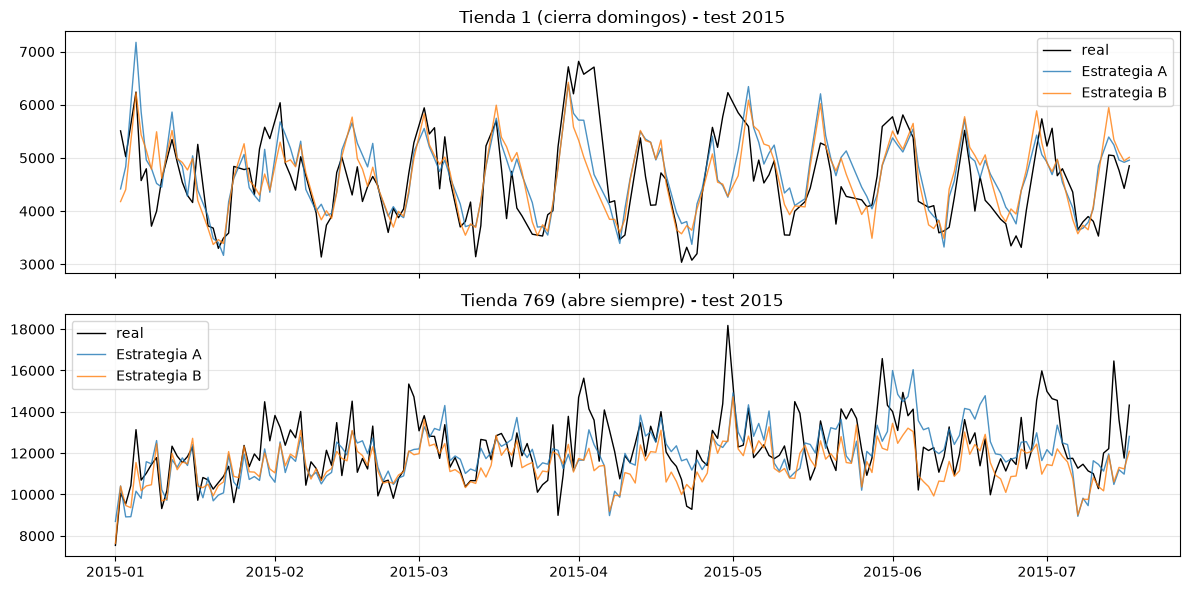

In [90]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, s in zip(axes, [1, 769]):
    gA = pred_A[pred_A.Store == s].sort_values('Date')
    gB = pred_B[pred_B.Store == s].sort_values('Date')
    ax.plot(pd.to_datetime(gA.Date), gA.real, label='real', lw=1, color='black')
    ax.plot(pd.to_datetime(gA.Date), gA.pred, label='Estrategia A', lw=1, alpha=0.8)
    ax.plot(pd.to_datetime(gB.Date), gB.pred, label='Estrategia B', lw=1, alpha=0.8)
    ax.set_title(f"Tienda {s} ({'cierra domingos' if s in GRUPO_D else 'abre siempre'}) - test 2015")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Se representan las predicciones de ambas estrategias frente al valor real en el test para una tienda de cada familia. En la tienda 1 se aprecia cómo ambas reproducen el patrón semanal y los picos de promoción; en la tienda 769, de serie más plana, las diferencias entre estrategias se concentran en el ajuste fino del nivel día a día.

## 9. Reflexión final

- **La decisión de mayor impacto no fue la arquitectura sino el objetivo.** Prediciendo `log(1+Sales)`
  directamente, los modelos quedaban por debajo del baseline de medias: les costaba fijar el nivel de
  cada tienda. Reformular el objetivo como residuo respecto a la media (tienda, día de la semana)
  incorpora el baseline dentro del modelo y deja que la red aprenda solo las desviaciones (promociones,
  festivos, dinámica reciente). Con pocos datos, dar al modelo el punto de partida correcto vale más que
  añadir capas.

- **Especialización frente a datos.** Las dos estrategias ocupan puntos distintos del espectro: A maximiza
  la especialización (cada serie tiene su red) al precio de entrenar con muy pocos datos por modelo y de
  no poder transferir patrones comunes; B agrupa tiendas estructuralmente parecidas, gana datos por
  modelo y mantiene la identidad de cada tienda vía embedding. La comparativa de la sección 8 cuantifica
  ese intercambio sobre el mismo test.

- **R² frente a RMSPE.** El R² agregado favorece a quien acierta en las tiendas de mayor varianza; el
  RMSPE mide el error relativo y es más justo tienda a tienda. Las tiendas que abren siempre obtienen
  RMSPE excelentes con R² individuales bajos porque su serie apenas tiene varianza que explicar: un R²
  por tienda bajo no debe leerse como mal ajuste sin mirar el error relativo.

- **Líneas de mejora.** Búsqueda de hiperparámetros más amplia e independiente por estrategia, más
  semillas en los ensembles, calendario de festivos regional alemán como exógena adicional, y la
  extensión natural del espectro: el modelo global con las 1.115 tiendas y embedding de `Store`, que
  permitiría además inicializar los modelos especializados por *fine-tuning*.